# 03 — CGAN Training_v2

Treina um **Conditional GAN (CGAN)** para gerar imagens sintéticas de borboletas condicionadas à classe.


# Análise de Resultados — Fase 1 (CGAN, config. fixa)

## Métricas de Qualidade das Imagens Geradas

| Métrica | Obtido | Referência (64×64) | Interpretação |
|---|---|---|---|
| **FID** ↓ | 221.76 | < 50 bom, < 100 aceitável | Distribuição gerada afastada da real |
| **IS** ↑ | 3.18 ± 0.92 | > 5 bom | Baixa qualidade e diversidade |
| **SSIM** ↑ | 0.0545 | > 0.3 bom | Estrutura visual muito diferente das reais |

---

## Análise das Loss Curves do GAN

### Generator vs Discriminator
O gráfico de loss revela um padrão típico de **desequilíbrio entre G e D**:

- O **Discriminador** estabiliza muito rapidamente em ~0.5, o que à partida parece o equilíbrio ideal (Nash equilibrium), mas aqui acontece demasiado cedo — o D aprendeu a separar reais de falsas antes de o G ter aprendido a gerar imagens convincentes.
- O **Generator** começa com loss ~4.2 e desce lentamente até ~1.4 ao fim de 200 epochs, sem nunca convergir de forma estável. A oscilação persistente indica que o G está a lutar contra um D já bem treinado, sem conseguir melhorar de forma consistente.

### Discriminator: Real vs Fake
- **D(real)** mantém-se em ~0.55–0.62, o que significa que o D classifica as imagens reais como "provavelmente reais" mas com pouca confiança.
- **D(fake)** estabiliza em ~0.40, indicando que o D consegue distinguir as imagens geradas das reais com alguma facilidade.
- A diferença entre D(real) e D(fake) nunca convergiu para 0, confirmando que o G **não enganou o D** de forma consistente ao longo do treino.

### Conclusão do GAN
O treino não colapsou completamente (o G não gerou imagens todas iguais), mas também não convergiu para um bom equilíbrio. O FID de 222.88 reflete isto — as imagens geradas têm estrutura suficiente para não serem ruído puro, mas estão longe de ser visualmente convincentes como borboletas reais.

---

## Análise das Curvas do Baseline Aumentado

O classificador treinado com o dataset aumentado (imagens reais + geradas pelo CGAN) apresenta:

- **Val accuracy final: ~0.68** ao fim de 50 epochs, com a curva ainda a crescer — o modelo não saturou, poderia beneficiar de mais epochs.
- A **train accuracy (~0.80)** está acima da val accuracy, indicando algum overfitting, mas o gap é razoável (~0.12), não preocupante.
- As **loss curves** são saudáveis — ambas a descer de forma consistente, sem divergência, o que mostra que as imagens geradas, apesar de baixa qualidade visual, não prejudicaram o treino do classificador.

---

## O que fazer a seguir (Fase 2)

Com base nestas observações, a **Fase 2** deve explorar os seguintes ajustes prioritários:

| Ajuste | Motivação |
|---|---|
| `n_critic = 2` | D ficou forte demasiado cedo — dar 2 passos ao G por cada passo do D equilibra o treino |
| `latent_dim = 128` | manter |
| `lr_G = 2e-4, lr_D = 5e-5` | Reduzir o LR do D para abrandar a sua aprendizagem relativa ao G |
| `label_smoothing = 0.1` | Já aplicado — manter, pois impede o D de ficar demasiado confiante |
| `epochs = 400` | A loss do G ainda estava a descer aos 200 epochs — mais tempo pode ajudar |

A métrica de seleção na grid search será o **FID**, calculado com 400 imagens após `GRID_EPOCHS = 25` epochs de treino rápido por configuração.

In [14]:
import os, sys, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torchvision.utils as vutils
import torchvision.transforms as T
from torch.utils.data import DataLoader

# ── Paths ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(os.path.abspath("__file__")).parent
SRC_DIR      = (NOTEBOOK_DIR / "../src").resolve()
CKPT_DIR     = (NOTEBOOK_DIR / "../outputs/checkpoints/gan").resolve()
SAMPLE_DIR   = (NOTEBOOK_DIR / "../outputs/figures/gan_samples").resolve()

sys.path.insert(0, str(SRC_DIR))

CKPT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

# ── Dataset via kagglehub (mesmo método do notebook 00) ──────────────────────
import kagglehub
dataset_path = Path(kagglehub.competition_download("aca-tp-2"))

train_dir = dataset_path / "train"
test_dir  = dataset_path / "test"
train_csv_path = dataset_path / "train.csv"

print(f"Dataset path : {dataset_path}")
print(f"Train images : {len(list(train_dir.iterdir()))} ficheiros")
print(f"Device       : ", end="")

from gan_v2 import Generator, Discriminator, build_cgan, real_label, fake_label, LATENT_DIM
from dataset import ButterflyDataset
from utils   import get_splits, GLOBAL_SEED

device = (
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print(device)
torch.manual_seed(GLOBAL_SEED)


Dataset path : /Users/ritapduarte/.cache/kagglehub/competitions/aca-tp-2
Train images : 5199 ficheiros
Device       : mps


## Hiperparâmetros

In [ ]:
# ── Treino ──────────────────────────────────────────────────────────────────
NUM_EPOCHS      = 400        # epochs totais
BATCH_SIZE      = 64
LR_G            = 2e-4       # learning rate do Generator
LR_D            = 5e-5       # alterou-se
BETA1           = 0.5        # Adam beta1 (standard para GANs)
BETA2           = 0.999      # Adam beta2
LABEL_SMOOTHING = 0.1        # manteve-se para impedir o D de ficar muito confiante 
N_CRITIC        = 2          # Aumentou-se porque D se revelou muito fraco

# ── Modelo ──────────────────────────────────────────────────────────────────
LATENT_DIM_CFG = 128   # igual à fase 1
RESUME         = True  
CLASS_EMB_DIM   = 64
NUM_CLASSES     = 75

# ── Checkpoints ─────────────────────────────────────────────────────────────
SAVE_EVERY      = 10         # guardar checkpoint a cada N epochs
N_SAMPLE_IMGS   = 75         # 1 imagem por classe nas grelhas de visualização

print("Hiperparâmetros definidos.")


Hiperparâmetros definidos.


## Dataset e DataLoader

Usa a mesma transform do autoencoder: redimensionar para 64×64 e normalizar para [-1, 1] (compatível com Tanh do G).

In [15]:
# Transform para o GAN: imagens em [-1, 1]  (Tanh no G)
gan_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),   # [-1, 1]
])

train_csv = pd.read_csv(train_csv_path)
train_df, val_df = get_splits(train_csv, seed=GLOBAL_SEED)

# Mapeamento de classes (garantir consistência com class_to_idx.json)
with open( "class_to_idx.json") as f:
    class_to_idx = json.load(f)

# Adiciona coluna label_idx ao dataframe
train_df = train_df.copy()
train_df["label_idx"] = train_df["label"].map(class_to_idx)

train_dataset = ButterflyDataset(
    train_df,
    img_dir=str(train_dir),
    transform=gan_transform,
)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=(device == "cuda"),
    drop_last=True,
)

print(f"Treino  : {len(train_dataset)} imagens | {len(train_loader)} batches por epoch")
print(f"Classes : {NUM_CLASSES}")


Treino  : 4159 imagens | 64 batches por epoch
Classes : 75


## Inicialização dos Modelos, Otimizadores e Loss

In [18]:
G, D = build_cgan(
    latent_dim=LATENT_DIM_CFG,
    class_emb_dim=CLASS_EMB_DIM,
    num_classes=NUM_CLASSES,
    device=device,
)

optimizer_G = torch.optim.Adam(G.parameters(), lr=LR_G,  betas=(BETA1, BETA2))
optimizer_D = torch.optim.Adam(D.parameters(), lr=LR_D,  betas=(BETA1, BETA2))

# Substitui as duas linhas do StepLR por:
scheduler_G = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_G, T_max=NUM_EPOCHS - start_epoch, eta_min=5e-5)
scheduler_D = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_D, T_max=NUM_EPOCHS - start_epoch, eta_min=1e-5)
criterion = nn.BCEWithLogitsLoss()   # mais estável numericamente que BCE

# Ruído fixo para visualização consistente ao longo do treino
fixed_z      = torch.randn(N_SAMPLE_IMGS, LATENT_DIM_CFG, device=device)
fixed_labels = torch.arange(NUM_CLASSES, device=device)   # 1 imagem por classe

print(G)
print("\n", D)


Generator(
  (class_emb): Embedding(75, 64)
  (fc): Linear(in_features=192, out_features=8192, bias=True)
  (deconv): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): Tanh()
  )
)

 Discriminator(
  (class_emb): Embedding(75, 64)
  (class_proj): Linear(in_features=64, out_features=4096, bias=True)
  (conv): Sequential(
    (0): Conv

## Funções Auxiliares

In [100]:
def save_checkpoint(epoch, G, D, opt_G, opt_D, losses, filename):
    """Guarda estado completo para retomar treino."""
    torch.save({
        "epoch":          epoch,
        "G_state_dict":   G.state_dict(),
        "D_state_dict":   D.state_dict(),
        "optG_state_dict": opt_G.state_dict(),
        "optD_state_dict": opt_D.state_dict(),
        "losses":         losses,
    }, filename)


def load_checkpoint(filename, G, D, opt_G, opt_D):
    """Carrega checkpoint e retorna epoch de início e histórico de losses."""
    ckpt = torch.load(filename, map_location=device)
    G.load_state_dict(ckpt["G_state_dict"])
    D.load_state_dict(ckpt["D_state_dict"])
    opt_G.load_state_dict(ckpt["optG_state_dict"])
    opt_D.load_state_dict(ckpt["optD_state_dict"])
    print(f"Checkpoint carregado: epoch {ckpt['epoch']}")
    return ckpt["epoch"] + 1, ckpt["losses"]


def save_sample_grid(G, z, labels, epoch, save_dir, nrow=15):
    """Gera e guarda uma grelha de imagens sintéticas."""
    G.eval()
    with torch.no_grad():
        imgs = G(z, labels)                          # [-1, 1]
        imgs = (imgs * 0.5 + 0.5).clamp(0, 1)       # [0, 1]
    grid = vutils.make_grid(imgs, nrow=nrow, padding=2, normalize=False)
    vutils.save_image(grid, save_dir / f"samples_epoch_{epoch:04d}.png")
    G.train()
    return grid


print("Funções auxiliares definidas.")


Funções auxiliares definidas.


## Loop de Treino

### Algoritmo CGAN por epoch:

**Passo D** (para cada batch real):
1. Forward de imagens reais com labels corretas → loss_D_real  
2. Gerar imagens falsas com labels aleatórias → loss_D_fake  
3. loss_D = (loss_D_real + loss_D_fake) / 2 → backward + step  

**Passo G** (a cada N_CRITIC passos do D):
1. Gerar imagens falsas, fazer forward no D  
2. Target = 1 (queremos enganar D) → loss_G → backward + step


In [ ]:
def load_checkpoint(filename, G, D, opt_G, opt_D):
    """Carrega checkpoint e retorna epoch de início e histórico de losses."""
    ckpt = torch.load(filename, map_location=device)
    G.load_state_dict(ckpt["G_state_dict"])
    D.load_state_dict(ckpt["D_state_dict"])
    opt_G.load_state_dict(ckpt["optG_state_dict"])
    opt_D.load_state_dict(ckpt["optD_state_dict"])
    print(f"Checkpoint carregado: epoch {ckpt['epoch']}")
    return ckpt["epoch"] + 1, ckpt["losses"]

# ── Retomar de checkpoint se existir ────────────────────────────────────────
latest_ckpt = sorted(CKPT_DIR.glob("ckpt_epoch_*.pt"))
start_epoch = 0
history = {"loss_G": [], "loss_D": [], "loss_D_real": [], "loss_D_fake": []}

RESUME = True   

if latest_ckpt and RESUME:
    start_epoch, history = load_checkpoint(
        latest_ckpt[-1], G, D, optimizer_G, optimizer_D
    )
    
# ── Treino ───────────────────────────────────────────────────────────────────
print(f"Início do treino: epochs {start_epoch} → {NUM_EPOCHS}")

for epoch in range(start_epoch, NUM_EPOCHS):
    G.train(); D.train()
    epoch_loss_G, epoch_loss_D, epoch_loss_Dr, epoch_loss_Df = 0., 0., 0., 0.
    t0 = time.time()

    for i, (real_imgs, labels) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        labels    = labels.to(device)
        batch_sz  = real_imgs.size(0)

        # ── Treinar Discriminador ─────────────────────────────────────────
        optimizer_D.zero_grad()

        # Real
        out_real  = D(real_imgs, labels)
        loss_D_r  = criterion(out_real, real_label(batch_sz, device, LABEL_SMOOTHING))

        # Falso
        z           = torch.randn(batch_sz, LATENT_DIM_CFG, device=device)
        fake_labels = torch.randint(0, NUM_CLASSES, (batch_sz,), device=device)
        fake_imgs   = G(z, fake_labels).detach()    # .detach() para não propagar para G
        out_fake    = D(fake_imgs, fake_labels)
        loss_D_f    = criterion(out_fake, fake_label(batch_sz, device))

        loss_D = (loss_D_r + loss_D_f) * 0.5
        loss_D.backward()
        optimizer_D.step()

        # ── Treinar Generator (a cada N_CRITIC passos do D) ──────────────
        if i % N_CRITIC == 0:
            optimizer_G.zero_grad()

            z           = torch.randn(batch_sz, LATENT_DIM_CFG, device=device)
            fake_labels = torch.randint(0, NUM_CLASSES, (batch_sz,), device=device)
            fake_imgs   = G(z, fake_labels)
            out_fake_g  = D(fake_imgs, fake_labels)

            # G quer que D classifique as fakes como reais
            loss_G = criterion(out_fake_g, real_label(batch_sz, device, smoothing=0.0))
            loss_G.backward()
            optimizer_G.step()

        epoch_loss_G  += loss_G.item()
        epoch_loss_D  += loss_D.item()
        epoch_loss_Dr += loss_D_r.item()
        epoch_loss_Df += loss_D_f.item()

    # ── Médias por epoch ──────────────────────────────────────────────────
    n = len(train_loader)
    history["loss_G"].append(epoch_loss_G / n)
    history["loss_D"].append(epoch_loss_D / n)
    history["loss_D_real"].append(epoch_loss_Dr / n)
    history["loss_D_fake"].append(epoch_loss_Df / n)

    scheduler_G.step()
    scheduler_D.step()

    elapsed = time.time() - t0
    print(
        f"Epoch [{epoch+1:03d}/{NUM_EPOCHS}] "
        f"loss_G={history['loss_G'][-1]:.4f}  "
        f"loss_D={history['loss_D'][-1]:.4f}  "
        f"(D_real={history['loss_D_real'][-1]:.4f}, D_fake={history['loss_D_fake'][-1]:.4f})  "
        f"[{elapsed:.1f}s]"
    )

    # ── Guardar amostras visuais ──────────────────────────────────────────
    if (epoch + 1) % SAVE_EVERY == 0 or epoch == 0:
        save_sample_grid(G, fixed_z, fixed_labels, epoch + 1, SAMPLE_DIR)

    # ── Checkpoint periódico ──────────────────────────────────────────────
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = CKPT_DIR / f"ckpt_epoch_{epoch+1:04d}.pt"
        save_checkpoint(epoch, G, D, optimizer_G, optimizer_D, history, ckpt_path)
        print(f"  ✔ Checkpoint guardado: {ckpt_path.name}")

print("\n Treino concluído!")


Checkpoint carregado: epoch 399
Início do treino: epochs 400 → 400

 Treino concluído!


## Guardar Modelo Final

In [ ]:
# Guardar apenas os state_dicts do modelo final 
torch.save(G.state_dict(), CKPT_DIR / "generator_final.pt")
torch.save(D.state_dict(), CKPT_DIR / "discriminator_final.pt")

# Guardar também um checkpoint completo final (para retomar ou fine-tuning)
save_checkpoint(
    NUM_EPOCHS - 1, G, D, optimizer_G, optimizer_D,
    history,
    CKPT_DIR / "ckpt_final.pt",
)

# Guardar configuração usada
config = {
    "latent_dim":      LATENT_DIM_CFG,
    "class_emb_dim":   CLASS_EMB_DIM,
    "num_classes":     NUM_CLASSES,
    "num_epochs":      NUM_EPOCHS,
    "batch_size":      BATCH_SIZE,
    "lr_G":            LR_G,
    "lr_D":            LR_D,
    "beta1":           BETA1,
    "beta2":           BETA2,
    "label_smoothing": LABEL_SMOOTHING,
    "n_critic":        N_CRITIC,
}
import json
with open(CKPT_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Modelo final guardado em:", CKPT_DIR)


Modelo final guardado em: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/outputs/checkpoints/gan


## Curvas de Loss

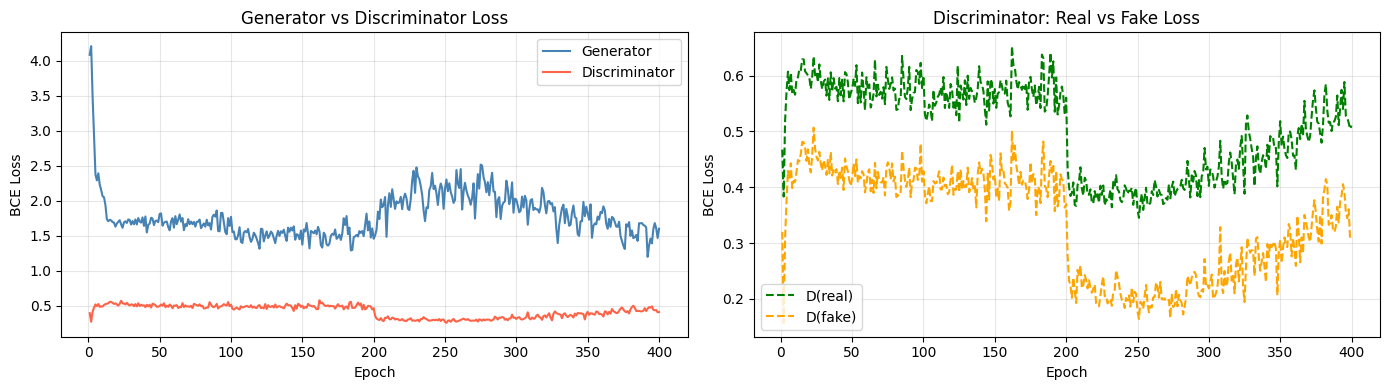

Curvas guardadas.


In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs_range = range(1, len(history["loss_G"]) + 1)

# Loss G vs D
axes[0].plot(epochs_range, history["loss_G"], label="Generator",     color="steelblue")
axes[0].plot(epochs_range, history["loss_D"], label="Discriminator", color="tomato")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Generator vs Discriminator Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# D decomposição
axes[1].plot(epochs_range, history["loss_D_real"], label="D(real)", color="green",  linestyle="--")
axes[1].plot(epochs_range, history["loss_D_fake"], label="D(fake)", color="orange", linestyle="--")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("BCE Loss")
axes[1].set_title("Discriminator: Real vs Fake Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAMPLE_DIR / "loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Curvas guardadas.")


## Visualização Final das Imagens Geradas

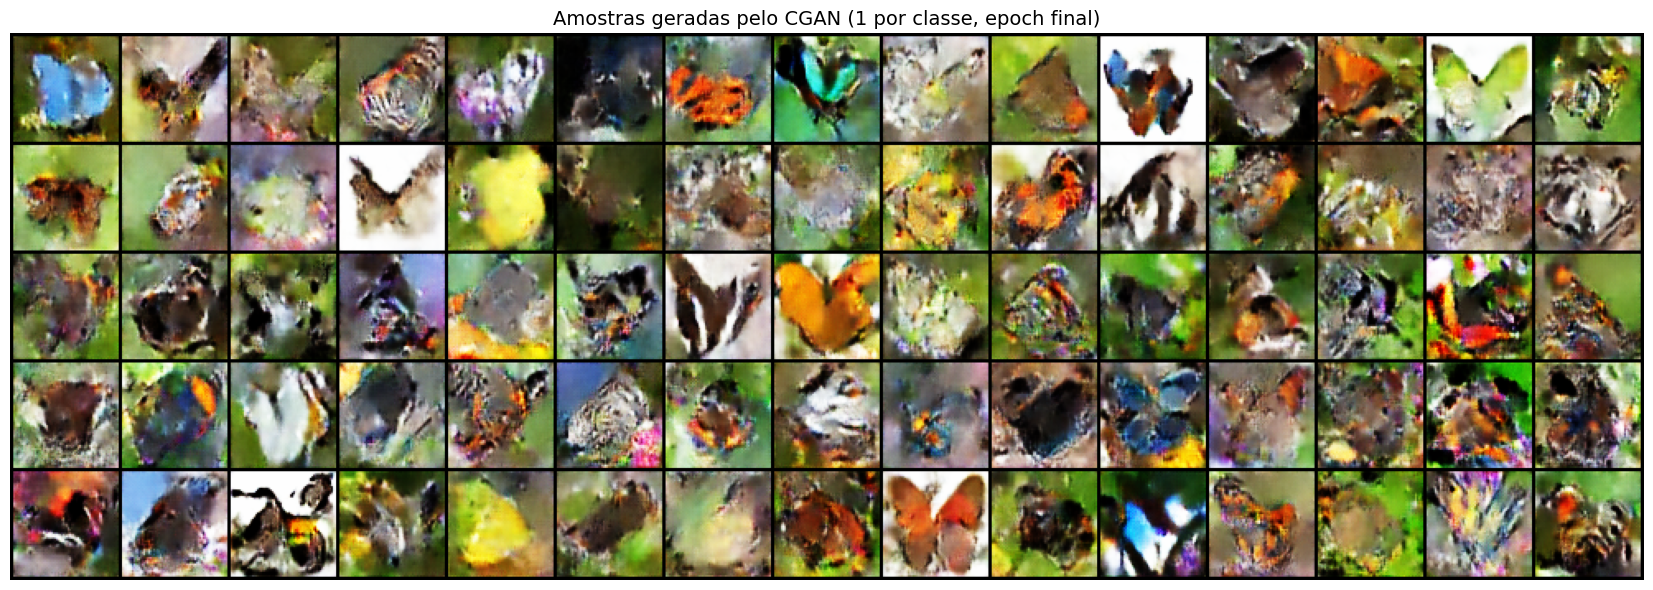

In [104]:
# Carrega o generator final e gera uma grelha de amostras
G.eval()
with torch.no_grad():
    sample_imgs = G(fixed_z, fixed_labels)
    sample_imgs = (sample_imgs * 0.5 + 0.5).clamp(0, 1).cpu()

grid = vutils.make_grid(sample_imgs, nrow=15, padding=2)
fig, ax = plt.subplots(figsize=(20, 6))
ax.imshow(grid.permute(1, 2, 0).numpy())
ax.axis("off")
ax.set_title("Amostras geradas pelo CGAN (1 por classe, epoch final)", fontsize=14)
plt.tight_layout()
plt.savefig(SAMPLE_DIR / "final_samples.png", dpi=150, bbox_inches="tight")
plt.show()


---
# Parte 04 — Gerar Dataset Aumentado

Usa o Generator treinado para criar **N imagens sintéticas por classe** e guarda-as em `data/generated/`.  
O dataset aumentado = imagens originais + imagens geradas.


In [8]:
# ── Configuração da geração ───────────────────────────────────────────────────
N_GENERATED_PER_CLASS = 50
GENERATED_DIR = (NOTEBOOK_DIR / "../data/generated/gan_fase2").resolve()
AUGMENTED_DIR = (NOTEBOOK_DIR / "../data/augmented/gan_fase2").resolve()

GENERATED_DIR.mkdir(parents=True, exist_ok=True)
AUGMENTED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Geradas em  : {GENERATED_DIR}")
print(f"Aumentado em: {AUGMENTED_DIR}")

Geradas em  : /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/data/generated/gan_fase2
Aumentado em: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/data/augmented/gan_fase2


Features reais: (400, 2048)
  ckpt_epoch_0010.pt  (latent=128)  →  FID = 294.02
  ckpt_epoch_0020.pt  (latent=128)  →  FID = 291.78
  ckpt_epoch_0030.pt  (latent=128)  →  FID = 288.93
  ckpt_epoch_0040.pt  (latent=128)  →  FID = 283.90
  ckpt_epoch_0050.pt  (latent=128)  →  FID = 277.45
  ckpt_epoch_0060.pt  (latent=128)  →  FID = 265.29
  ckpt_epoch_0070.pt  (latent=128)  →  FID = 251.55
  ckpt_epoch_0080.pt  (latent=128)  →  FID = 240.32
  ckpt_epoch_0090.pt  (latent=128)  →  FID = 237.21
  ckpt_epoch_0100.pt  (latent=128)  →  FID = 230.83
  ckpt_epoch_0110.pt  (latent=128)  →  FID = 238.22
  ckpt_epoch_0120.pt  (latent=128)  →  FID = 228.73
  ckpt_epoch_0130.pt  (latent=128)  →  FID = 220.72
  ckpt_epoch_0140.pt  (latent=128)  →  FID = 227.47
  ckpt_epoch_0150.pt  (latent=128)  →  FID = 220.95
  ckpt_epoch_0160.pt  (latent=128)  →  FID = 220.26
  ckpt_epoch_0170.pt  (latent=128)  →  FID = 224.21
  ckpt_epoch_0180.pt  (latent=128)  →  FID = 232.44
  ckpt_epoch_0190.pt  (latent=128)  

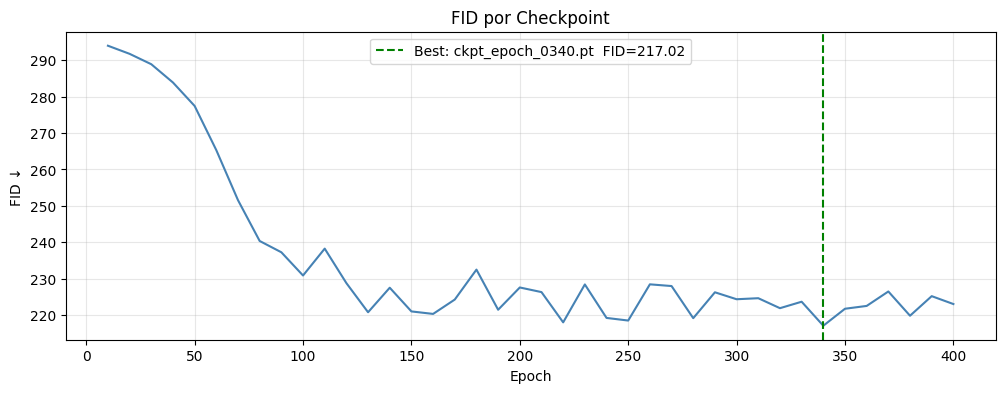

In [42]:
# ── Selecionar melhor checkpoint por FID ─────────────────────────────────────
from PIL import Image as PILImage
import torchvision.transforms as T

# Features das imagens reais (calculadas uma vez)
real_transform = T.Compose([T.Resize((64, 64)), T.ToTensor()])
real_sample_df = train_df.sample(400, random_state=GLOBAL_SEED)

real_tensors = []
for _, row in real_sample_df.iterrows():
    img = PILImage.open(train_dir / row["filename"]).convert("RGB")
    real_tensors.append(real_transform(img))
real_tensors = torch.stack(real_tensors)
real_feats   = get_inception_features(real_tensors)
print(f"Features reais: {real_feats.shape}")

# Loop por todos os checkpoints
torch.manual_seed(42)
z_fid      = torch.randn(400, 128, device=device)
labels_fid = torch.randint(0, NUM_CLASSES, (400,), device=device)

ckpt_list  = sorted(CKPT_DIR.glob("ckpt_epoch_*.pt"))
fid_results = []

for ckpt_path in ckpt_list:
    ckpt = torch.load(ckpt_path, map_location=device)
    fc_in          = ckpt["G_state_dict"]["fc.weight"].shape[1]
    latent_dim_ckpt = fc_in - CLASS_EMB_DIM

    G_eval, _ = build_cgan(latent_dim=latent_dim_ckpt,
                            class_emb_dim=CLASS_EMB_DIM,
                            num_classes=NUM_CLASSES, device=device)
    G_eval.load_state_dict(ckpt["G_state_dict"])
    G_eval.eval()

    z_tmp = torch.randn(400, latent_dim_ckpt, device=device)
    with torch.no_grad():
        fake = G_eval(z_tmp, labels_fid)
        fake = (fake * 0.5 + 0.5).clamp(0, 1)

    fake_feats = get_inception_features(fake)
    fid        = compute_fid(real_feats, fake_feats)
    fid_results.append((ckpt_path.name, fid, latent_dim_ckpt))
    print(f"  {ckpt_path.name}  (latent={latent_dim_ckpt})  →  FID = {fid:.2f}")

# Selecionar o melhor
best_ckpt_name, best_fid_val, best_latent_dim = min(fid_results, key=lambda x: x[1])
print(f"\n Melhor checkpoint: {best_ckpt_name}  (FID = {best_fid_val:.2f}, latent_dim = {best_latent_dim})")

# Plot
epochs_fid = [int(n.split("_")[2].split(".")[0]) for n, _, _ in fid_results]
fids       = [f for _, f, _ in fid_results]
plt.figure(figsize=(12, 4))
plt.plot(epochs_fid, fids, color="steelblue")
plt.axvline(x=int(best_ckpt_name.split("_")[2].split(".")[0]),
            color="green", linestyle="--", label=f"Best: {best_ckpt_name}  FID={best_fid_val:.2f}")
plt.xlabel("Epoch"); plt.ylabel("FID ↓")
plt.title("FID por Checkpoint")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(SAMPLE_DIR / "fid_per_checkpoint.png", dpi=150, bbox_inches="tight")
plt.show()

In [43]:
import torchvision.transforms.functional as TF

# Carregar o generator da fase 2
best_ckpt_name, best_fid_val, best_latent_dim = min(fid_results, key=lambda x: x[1])

G_best, _ = build_cgan(latent_dim=best_latent_dim,
                        class_emb_dim=CLASS_EMB_DIM,
                        num_classes=NUM_CLASSES, device=device)
ckpt = torch.load(CKPT_DIR / best_ckpt_name, map_location=device)
G_best.load_state_dict(ckpt["G_state_dict"])
G_best.eval()
print(f"Generator carregado: {best_ckpt_name}  (FID checkpoint = {best_fid_val:.2f})")

idx_to_class = {v: k for k, v in class_to_idx.items()}

def tensor_to_pil(t):
    t = (t * 0.5 + 0.5).clamp(0, 1)
    return TF.to_pil_image(t.cpu())

generated_records = []

print(f"A gerar {N_GENERATED_PER_CLASS} imagens × {NUM_CLASSES} classes = "
      f"{N_GENERATED_PER_CLASS * NUM_CLASSES} imagens...")

with torch.no_grad():
    for class_idx in range(NUM_CLASSES):
        class_name = idx_to_class[class_idx]
        class_dir  = GENERATED_DIR / class_name.replace(" ", "_")
        class_dir.mkdir(parents=True, exist_ok=True)

        labels = torch.full((N_GENERATED_PER_CLASS,), class_idx,
                            dtype=torch.long, device=device)
        z = torch.randn(N_GENERATED_PER_CLASS, best_latent_dim, device=device)
        imgs = G_best(z, labels)

        for j, img_t in enumerate(imgs):
            filename = f"{class_name.replace(' ', '_')}_{j:04d}.png"
            filepath = class_dir / filename
            tensor_to_pil(img_t).save(filepath)
            generated_records.append({
                "filename": str(filepath),
                "label":    class_name,
                "source":   "generated",
            })

print(f" {len(generated_records)} imagens geradas e guardadas em {GENERATED_DIR}")

Generator carregado: ckpt_epoch_0340.pt  (FID checkpoint = 217.02)
A gerar 50 imagens × 75 classes = 3750 imagens...
 3750 imagens geradas e guardadas em /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/data/generated/gan_fase2


In [44]:
# Imagens originais com paths absolutos
orig_df = train_df[["filename", "label"]].copy()
orig_df["filename"] = orig_df["filename"].apply(
    lambda f: str((train_dir / f).resolve())
)
orig_df["source"] = "original"

# Verificar que os paths existem
import os
missing = [f for f in orig_df["filename"] if not os.path.exists(f)]
print(f"Originais em falta: {len(missing)}")

# Juntar
gen_df       = pd.DataFrame(generated_records)
augmented_df = pd.concat([orig_df, gen_df], ignore_index=True)

augmented_csv_path = AUGMENTED_DIR / "augmented_train_gan_fase2.csv"
augmented_df.to_csv(augmented_csv_path, index=False)

print(f"Dataset aumentado: {len(augmented_df)} imagens "
      f"({len(orig_df)} originais + {len(gen_df)} geradas)")
print(f"CSV guardado em  : {augmented_csv_path}")
augmented_df.head()

Originais em falta: 0
Dataset aumentado: 7909 imagens (4159 originais + 3750 geradas)
CSV guardado em  : /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/data/augmented/gan_fase2/augmented_train_gan_fase2.csv


,filename,label,source
0,/Users/ritapduarte/.cache/kagglehub/competitio...,PURPLE HAIRSTREAK,original
1,/Users/ritapduarte/.cache/kagglehub/competitio...,SLEEPY ORANGE,original
2,/Users/ritapduarte/.cache/kagglehub/competitio...,MONARCH,original
3,/Users/ritapduarte/.cache/kagglehub/competitio...,GREAT EGGFLY,original
4,/Users/ritapduarte/.cache/kagglehub/competitio...,SILVER SPOT SKIPPER,original


---
# Parte 05 — Re-treinar a Baseline com Dataset Aumentado

Re-treina a **BaselineCNN sem qualquer alteração** (arquitetura, otimizador e loss idênticos ao baseline original), usando apenas o dataset aumentado.


In [50]:
from models     import BaselineCNN
from transforms import get_transforms
from sklearn.metrics import f1_score, accuracy_score
from tqdm.auto import tqdm
from PIL import Image as PILImage
# ── Hiperparâmetros IGUAIS ao 01_baseline_training.ipynb ─────────────────────
BASELINE_EPOCHS     = 150
BASELINE_LR         = 0.001
BASELINE_BATCH      = 32
EARLY_STOP_PATIENCE = 15

BASELINE_CKPT_DIR = (NOTEBOOK_DIR / "../outputs/checkpoints/baseline_augmented").resolve()
BASELINE_CKPT_DIR.mkdir(parents=True, exist_ok=True)

train_transform, val_transform = get_transforms()

class AugmentedDataset(torch.utils.data.Dataset):
    """Lê imagens por filepath absoluto — compatível com o CSV gerado acima."""
    def __init__(self, df, transform=None):
        self.df           = df.reset_index(drop=True)
        self.transform    = transform
        classes           = sorted(df["label"].unique())
        self.class_to_idx = {c: i for i, c in enumerate(classes)}

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = PILImage.open(row["filename"]).convert("RGB")
        if self.transform: image = self.transform(image)
        label = self.class_to_idx[row["label"]]
        return image, torch.tensor(label, dtype=torch.long)

# Validação apenas com imagens originais (comparação justa com o baseline)
_, val_df_orig = get_splits(train_csv, seed=GLOBAL_SEED)
val_df_orig = val_df_orig.copy()
val_df_orig["filename"] = val_df_orig["filename"].apply(
    lambda f: str((train_dir / f).resolve())
)

aug_train_ds = AugmentedDataset(augmented_df, transform=train_transform)
aug_val_ds   = AugmentedDataset(val_df_orig,  transform=val_transform)

aug_train_loader = DataLoader(aug_train_ds, batch_size=BASELINE_BATCH, shuffle=True,
                               num_workers=0, pin_memory=(device == "cuda"))
aug_val_loader   = DataLoader(aug_val_ds,   batch_size=BASELINE_BATCH, shuffle=False,
                               num_workers=0, pin_memory=(device == "cuda"))

print(f"Treino aumentado : {len(aug_train_ds)} imagens")
print(f"Validação        : {len(aug_val_ds)} imagens")

Treino aumentado : 7909 imagens
Validação        : 1040 imagens


In [ ]:
# ── Modelo, otimizador e loss — IGUAIS ao baseline original ──────────────────
baseline_aug = BaselineCNN(num_classes=NUM_CLASSES).to(device)
optimizer_b  = torch.optim.Adam(baseline_aug.parameters(), lr=BASELINE_LR)
criterion_b  = nn.CrossEntropyLoss()

best_val_f1           = 0.0
epochs_without_improv = 0
baseline_history      = {"train_loss": [], "val_loss": [],
                          "train_acc":  [], "val_acc":  [], "val_f1": []}

print("Início do treino da Baseline com dataset aumentado...")

for epoch in range(BASELINE_EPOCHS):
    baseline_aug.train()
    trn_loss, preds_all, labels_all = 0., [], []
    for imgs, labels in tqdm(aug_train_loader,
                             desc=f"Epoch {epoch+1}/{BASELINE_EPOCHS} [Train]",
                             leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer_b.zero_grad()
        out  = baseline_aug(imgs)
        loss = criterion_b(out, labels)
        loss.backward(); optimizer_b.step()
        trn_loss += loss.item() * imgs.size(0)
        preds_all.extend(out.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    trn_loss /= len(aug_train_ds)
    trn_acc   = accuracy_score(labels_all, preds_all)

    baseline_aug.eval()
    val_loss, preds_all, labels_all = 0., [], []
    with torch.no_grad():
        for imgs, labels in tqdm(aug_val_loader,
                                 desc=f"Epoch {epoch+1}/{BASELINE_EPOCHS} [Val]",
                                 leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            out       = baseline_aug(imgs)
            val_loss += criterion_b(out, labels).item() * imgs.size(0)
            preds_all.extend(out.argmax(1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    val_loss /= len(aug_val_ds)
    val_acc   = accuracy_score(labels_all, preds_all)
    val_f1    = f1_score(labels_all, preds_all, average="weighted")

    baseline_history["train_loss"].append(trn_loss)
    baseline_history["train_acc"].append(trn_acc)
    baseline_history["val_loss"].append(val_loss)
    baseline_history["val_acc"].append(val_acc)
    baseline_history["val_f1"].append(val_f1)

    print(f"Epoch {epoch+1:02d}/{BASELINE_EPOCHS} | "
          f"Train Loss: {trn_loss:.4f}  Acc: {trn_acc:.4f} || "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1           = val_f1
        epochs_without_improv = 0
        torch.save(baseline_aug.state_dict(),
                   BASELINE_CKPT_DIR / "baseline_augmented_best.pt")
        print(f"  ✔ Best model saved (Val F1: {best_val_f1:.4f})")
    else:
        epochs_without_improv += 1
        print(f"     No improvement for {epochs_without_improv} epoch(s).")
        if epochs_without_improv >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping após epoch {epoch+1}.")
            break

print(f"\n Melhor val F1: {best_val_f1:.4f}")

Início do treino da Baseline com dataset aumentado...


Epoch 1/150 [Train]:   0%|          | 0/248 [00:00<?, ?it/s]

Epoch 1/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 01/150 | Train Loss: 4.0239  Acc: 0.0360 || Val Loss: 3.8233  Acc: 0.0606  F1: 0.0147
  ✔ Best model saved (Val F1: 0.0147)


Epoch 2/150 [Train]:   0%|          | 0/248 [00:00<?, ?it/s]

...

Epoch 127/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 127/150 | Train Loss: 0.2759  Acc: 0.9188 || Val Loss: 0.7892  Acc: 0.7808  F1: 0.7789
     No improvement for 14 epoch(s).


Epoch 128/150 [Train]:   0%|          | 0/248 [00:00<?, ?it/s]

Epoch 128/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 128/150 | Train Loss: 0.2508  Acc: 0.9244 || Val Loss: 0.7681  Acc: 0.8058  F1: 0.8053
     No improvement for 15 epoch(s).

Early stopping após epoch 128.

 Melhor val F1: 0.8182


---
# Parte 06 — Avaliação e Plots

Calcula métricas de qualidade das imagens geradas:
- **FID** (Fréchet Inception Distance) — distância entre distribuições real e gerada (↓ melhor)
- **IS** (Inception Score) — qualidade + diversidade (↑ melhor)
- **SSIM** (Structural Similarity Index) — similaridade estrutural (↑ melhor)

E compara a performance do classificador **antes e depois** da augmentação.


In [45]:
# Instalar pytorch-fid se necessário
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "pytorch-fid", "scikit-image",
                "--quiet"], check=True)
print("Dependências instaladas.")


Dependências instaladas.


In [46]:
import warnings
warnings.filterwarnings("ignore")
from skimage.metrics import structural_similarity as ssim_fn
import torchvision.models as tv_models
import torch.nn.functional as F
from scipy import linalg

# ── Inception v3 para FID e IS ───────────────────────────────────────────────
inception = tv_models.inception_v3(weights="DEFAULT", transform_input=False).to(device)
inception.eval()

def get_inception_features(imgs_tensor):
    """Extrai features do penúltimo layer do Inception v3. imgs ∈ [0,1], (N,3,H,W)."""
    imgs_299 = F.interpolate(imgs_tensor, size=(299, 299), mode="bilinear", align_corners=False)
    with torch.no_grad():
        # Hook no avgpool para obter features 2048-d
        feats = []
        def hook(m, i, o): feats.append(o.squeeze(-1).squeeze(-1))
        h = inception.avgpool.register_forward_hook(hook)
        inception(imgs_299.to(device))
        h.remove()
    return feats[0].cpu().numpy()

def compute_fid(real_feats, fake_feats):
    """FID entre dois conjuntos de features numpy."""
    mu1, sigma1 = real_feats.mean(0), np.cov(real_feats, rowvar=False)
    mu2, sigma2 = fake_feats.mean(0), np.cov(fake_feats, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return float(diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean))

def compute_is(fake_feats_logits, splits=10):
    """Inception Score a partir dos logits do Inception (antes do softmax)."""
    pyx  = torch.softmax(torch.tensor(fake_feats_logits), dim=1).numpy()
    py   = pyx.mean(0)
    kl   = pyx * (np.log(pyx + 1e-8) - np.log(py + 1e-8))
    scores = np.exp(kl.sum(1))
    chunks = np.array_split(scores, splits)
    return float(np.mean([c.mean() for c in chunks])), float(np.std([c.mean() for c in chunks]))

print("Funções de avaliação definidas.")


Funções de avaliação definidas.


In [47]:

G_best.eval()
fake_tensors = []
with torch.no_grad():
    for class_idx in range(NUM_CLASSES):
        n   = max(1, 500 // NUM_CLASSES)
        lbl = torch.full((n,), class_idx, dtype=torch.long, device=device)
        z   = torch.randn(n, best_latent_dim, device=device)
        out = G_best(z, lbl)
        out = (out * 0.5 + 0.5).clamp(0, 1)
        fake_tensors.append(out.cpu())
fake_tensors = torch.cat(fake_tensors)


In [52]:
# Confirmar que o fake_tensors foi gerado pelo G_best
print(f"fake_tensors shape : {fake_tensors.shape}")
print(f"min: {fake_tensors.min():.3f}  max: {fake_tensors.max():.3f}")
print(f"std média por imagem: {fake_tensors.std(dim=[1,2,3]).mean():.4f}")
print(f"Checkpoint usado: {best_ckpt_name}  (FID = {best_fid_val:.2f})")

fake_tensors shape : torch.Size([450, 3, 64, 64])
min: 0.000  max: 1.000
std média por imagem: 0.2274
Checkpoint usado: ckpt_epoch_0340.pt  (FID = 217.02)


In [53]:
# ── FID ──────────────────────────────────────────────────────────────────────
fid_score = compute_fid(real_feats, fake_feats)
print(f"FID  : {fid_score:.2f}   (↓ melhor; <50 é razoável para 64×64)")

# ── IS ───────────────────────────────────────────────────────────────────────
# Para IS precisamos dos logits completos do Inception
fake_logits = []
with torch.no_grad():
    for i in range(0, len(fake_tensors), 64):
        batch = fake_tensors[i:i+64]
        batch_299 = F.interpolate(batch, size=(299,299), mode="bilinear", align_corners=False)
        logits = inception(batch_299.to(device)).cpu().numpy()
        fake_logits.append(logits)
fake_logits = np.concatenate(fake_logits)

is_mean, is_std = compute_is(fake_logits)
print(f"IS   : {is_mean:.2f} ± {is_std:.2f}   (↑ melhor)")

# ── SSIM ─────────────────────────────────────────────────────────────────────
n_pairs = min(200, len(real_tensors), len(fake_tensors))
ssim_scores = []
for i in range(n_pairs):
    r = real_tensors[i].permute(1,2,0).numpy()
    f = fake_tensors[i].permute(1,2,0).numpy()
    ssim_scores.append(ssim_fn(r, f, data_range=1.0, channel_axis=2))

ssim_mean = float(np.mean(ssim_scores))
print(f"SSIM : {ssim_mean:.4f}   (↑ melhor; 1.0 = idêntico)")


FID  : 222.98   (↓ melhor; <50 é razoável para 64×64)
IS   : 3.23 ± 0.96   (↑ melhor)
SSIM : 0.0534   (↑ melhor; 1.0 = idêntico)


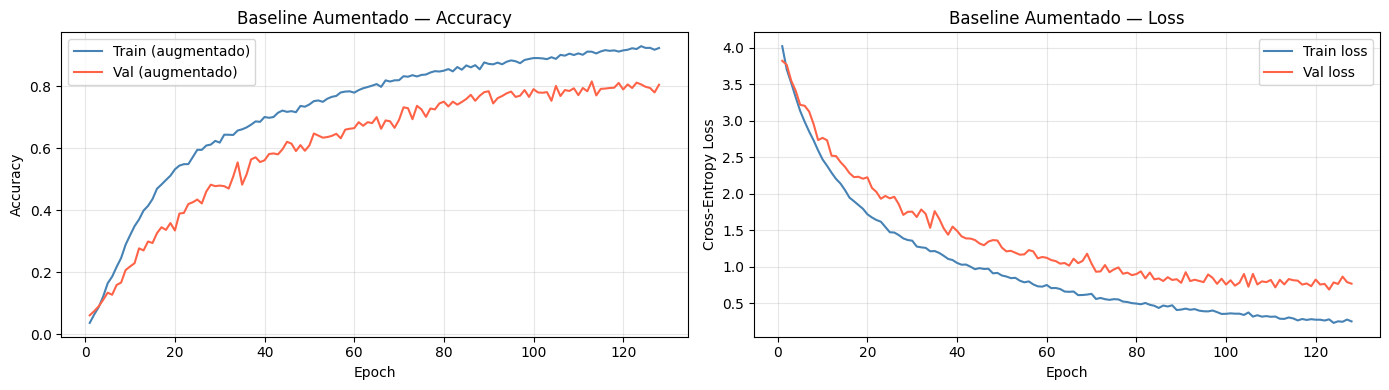


── Resumo de Métricas ──────────────────────────────────────────
  FID  (GAN)                : 222.98
  IS   (GAN)                : 3.23 ± 0.96
  SSIM (GAN vs Real)        : 0.0534
  Best val_F1 (augmentado) : 0.8182
────────────────────────────────────────────────────────────────


In [ ]:
# ── Curvas de treino: Baseline original vs Baseline aumentado ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs_aug = range(1, len(baseline_history["val_acc"]) + 1)

axes[0].plot(epochs_aug, baseline_history["train_acc"], label="Train (augmentado)", color="steelblue")
axes[0].plot(epochs_aug, baseline_history["val_acc"],   label="Val (augmentado)",   color="tomato")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("Baseline Aumentado — Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_aug, baseline_history["train_loss"], label="Train loss", color="steelblue")
axes[1].plot(epochs_aug, baseline_history["val_loss"],   label="Val loss",   color="tomato")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Cross-Entropy Loss")
axes[1].set_title("Baseline Aumentado — Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAMPLE_DIR / "baseline_augmented_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Tabela resumo ─────────────────────────────────────────────────────────────
print("\n── Resumo de Métricas ──────────────────────────────────────────")
print(f"  FID  (GAN)                : {fid_score:.2f}")
print(f"  IS   (GAN)                : {is_mean:.2f} ± {is_std:.2f}")
print(f"  SSIM (GAN vs Real)        : {ssim_mean:.4f}")
print(f"  Best val_F1 (augmentado) : {best_val_f1:.4f}")
print("────────────────────────────────────────────────────────────────")


---
# Parte 08 — Submissão Kaggle

Gera o ficheiro `submission.csv` com as previsões do modelo **Baseline treinado com dados aumentados** para o conjunto de teste (sem labels).


In [56]:
from models     import BaselineCNN
from transforms import get_transforms
from dataset    import ButterflyDataset

# ── Carregar o melhor modelo baseline aumentado ───────────────────────────────
BASELINE_CKPT  = (NOTEBOOK_DIR / "../outputs/checkpoints/baseline_augmented/baseline_augmented_best.pt").resolve()
SUBMISSION_DIR = (NOTEBOOK_DIR / "../outputs/submissions").resolve()
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

idx_to_class = {v: k for k, v in class_to_idx.items()}

model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(BASELINE_CKPT, map_location=device))
model.eval()
print(f"Modelo carregado: {BASELINE_CKPT.name}")


Modelo carregado: baseline_augmented_best.pt


In [57]:
# ── Dataset de teste (sem labels) ────────────────────────────────────────────
_, val_transform = get_transforms()

test_files = sorted(test_dir.iterdir())
test_df    = pd.DataFrame({"filename": [f.name for f in test_files]})

test_dataset = ButterflyDataset(
    test_df,
    img_dir=str(test_dir),
    transform=val_transform,
    is_test=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=(device == "cuda"),
)

print(f"Imagens de teste: {len(test_dataset)}")


Imagens de teste: 1300


In [58]:
# ── Inferência ────────────────────────────────────────────────────────────────
all_filenames = []
all_labels    = []

with torch.no_grad():
    for imgs, filenames in test_loader:
        imgs    = imgs.to(device)
        logits  = model(imgs)
        preds   = logits.argmax(dim=1).cpu().tolist()
        all_filenames.extend(filenames)
        all_labels.extend([idx_to_class[p] for p in preds])

print(f"Previsões geradas: {len(all_labels)}")


Previsões geradas: 1300


In [59]:
# ── Gerar CSV de submissão ────────────────────────────────────────────────────
submission_df = pd.DataFrame({
    "filename": all_filenames,
    "label":    all_labels,
})

submission_path = SUBMISSION_DIR / "submission_gan_augmented.csv"
submission_df.to_csv(submission_path, index=False)

print(f" Submissão guardada: {submission_path}")
print(f"   {len(submission_df)} linhas | {submission_df['label'].nunique()} classes distintas")
submission_df.head(10)


 Submissão guardada: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/outputs/submissions/submission_gan_augmented.csv
   1300 linhas | 75 classes distintas


,filename,label
0,Image_0.jpg,RED ADMIRAL
1,Image_1.jpg,APPOLLO
2,Image_10.jpg,PIPEVINE SWALLOW
3,Image_100.jpg,RED SPOTTED PURPLE
4,Image_1000.jpg,MALACHITE
5,Image_1001.jpg,MILBERTS TORTOISESHELL
6,Image_1002.jpg,EASTERN PINE ELFIN
7,Image_1003.jpg,CLEOPATRA
8,Image_1004.jpg,PIPEVINE SWALLOW
9,Image_1005.jpg,GREAT JAY


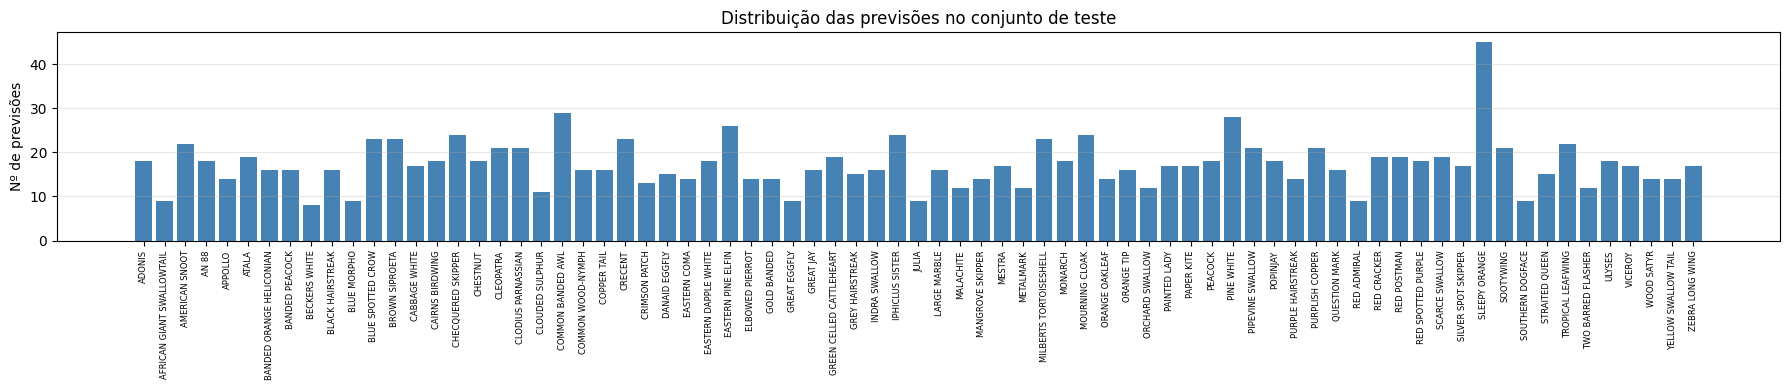

In [60]:
# ── Verificação rápida da distribuição de previsões ──────────────────────────
fig, ax = plt.subplots(figsize=(18, 4))
counts  = submission_df["label"].value_counts().sort_index()
ax.bar(range(len(counts)), counts.values, color="steelblue")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=90, fontsize=6)
ax.set_ylabel("Nº de previsões")
ax.set_title("Distribuição das previsões no conjunto de teste")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(SUBMISSION_DIR / "submission_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
